# Inductive Conformal Prediction


Traditional machine learning models output a point value (regression) or class (classification) but do not provide rigorous guarantees about uncertainty.

Inductive conformal prediction (CP) addresses this limitation by transforming model outputs into prediction intervals (regression) or sets (classification) with statistical coverage guarantees. For a chosen confidence level (e.g. 95%), CP guarantees that the true label will be contained in the prediction set at least 95% of the time, assuming data sets are exchangeable (*marginal coverage guarantee*). Exchangability is a weaker assumption than independent and identically distributed (i.i.d.) data, which is typically assumed in machine learning.

The theoretical part of the notebook is based on [this publication](https://arxiv.org/abs/2107.07511). For more in-depth explanation, we refer the reder therefore to Angelopoulos and Bates.

## Theory

Given i.i.d. data and a machine learning (ML) model that provides a notion of uncertainty, inductive
CP quantifies the predictive uncertainty for a sample. Using this information,
the CP framework can modify the predictions such that a minimum level of certainty for
the prediction is guaranteed. The minimum certainty level can be determined, given a
user-specified maximum error level α ∈ [0, 1], also known as *significance level*. The
minimum certainty is then given by 1−α. To achieve this minimum certainty level, CP
adheres to the idea of predicting sets or intervals instead of single points: For classification,
instead of predicting a single class for each sample, we predict a set of classes that
is guaranteed to contain the true class with a probability of at least 1 − α. In analogy, instead of casting point predictions in the regression setting, we obtain intervals that
cover the true value with a guaranteed probability of at least 1−α.



Training an ML model typically requires at least two disjoint datasets drawn i.i.d.,
namely training and test set. To guarantee certainties with CP, it would
be enough if the data is exchangeable, which is a weaker assumption than i.i.d..
However, since the framework is on top of an ML pipeline, we still assume that the samples
are draw i.i.d., i.e., we assume exchangeability by implication. In addition to the
training and test sets, CP requires a third set, which is called calibration dataset. The
calibration dataset contains ncal samples, which are pairwise disjoint from the samples
in training and test set. We need the calibration set to be disjoint from the training
and test sets because we use it to construct a statistic on the uncertainty, which should
be representative for unseen samples: If we used the training set, the statistic would
be unrepresentative for new instances, and if we used the test data, we would have an
unfair advantage when using the test data for final evaluation.
Generally, CP consists of three steps, where for each step we need another one of the
three datasets, which are pairwise disjoint:
1. Training set: Used to train the model as for ordinary ML.
2. Calibration set: Used to generate a statistic on the uncertainty of the model for
unseen instances. The notions of uncertainty are based on the true corresponding
output. They are used to derive a threshold, which corresponds to the desired
certainty level.
3. Test set: Used to evaluate the model predictions on previously unseen samples.
Instead of point predictions, however, the threshold from step 2 is used to obtain sets and intervals that are guaranteed to contain the true response with at least
probability 1 − α.

![cp_workflow](images/CP_workflow.png "CP workflow")

By performing CP as outlined above, the so-called *marginal coverage* is guaranteed, i.e.,
the probability that the true response yi for a sample i in the test set is contained in
the predicted set or interval $\hat{y}_i$ is:

$\forall i: 1- \alpha \leq P(y_i \in \hat{y}_i) \leq 1 - \alpha \frac{1}{n_{cal} + 1}$


The upper bound depends on the number of calibration samples. For ncal → ∞, the
probability of hitting the true value is exactly 1 − α. Since we do not have infinitely
many calibration samples, there is a range, in which the probability lies, caused by the
randomness in the data.


### Inductive CP for Classification

As mentioned in Chapter 3, we restrict our descriptions to binary classification, where
we call the two classes 0 and 1. Consequently, there are only 4 possible sets that can be
output by CP: {}, {0}, {1}, and {0, 1}. There are possible interpretations for either of
the aforementioned outcomes: If the model outputs one of the two sets only containing
one class, i.e., {0} and {1}, it is confident enough to predict for this sample. Especially
in the binary classification setting, we are interested in obtaining many single class
predictions. For CP, the so-called *efficiency* is a measure for the number of single class
predictions among all predictions. It is defined as the fraction of the number of single
class predictions by the total number of predictions. Consequently, predicting {0, 1}
for all samples gives us a coverage of 100% as the set must contain the true class by
definition, but the efficiency will be 0. If the model predicts the empty set or
the set containing both classes, it was not confident enough to cast a prediction. For the
empty set, none of the classes was likely enough to be predicted, e.g., the sample may
not be similar to the previously seen data. In contrary, the set containing both classes
indicates that both classes are likely, e.g., the sample may lie in a region close to the
threshold that separated the two classes and, therefore, the model was unsure to which
class the sample actually belongs.

### Calibration

The main difference between CP and ordinary ML is the second step mentioned above: Using the calibration dataset to obtain a statistic on the model uncertainty. To this end, we require a notion of uncertainty that we refer to as *(non-)conformity score*. In this notebook, we will only focus on a specific score that measures non-conformity, which we call the *true class score*.

For a given sample $x_i$, the non-conformity score is based on the true class $c_i$ and its corresponding prediction probability $P(c_i|x_i)$

$TC({x_i}) = 1 - P(c_i|x_i)$


A low score corresponds to being correct with a high probabiliyt, while a high score means that the model was wrong with a high probability.

During calibration, we determine a threshold ($\hat{q}$) corresponding to the maximum probability of being wrong that can be tolerated, while still achieving the desired coverage guarantee. This threshold is estimated from the calibration set and represents the largest non-conformity score that is acceptable for a prediction to be considered reliable.

These non-conformity scores from the calibration samples form an empirical reference distribution.

The conformal threshold ($\hat{q}$) is derived from the empircal quantile of this distribution
and determines how prediction sets are constructed for unseen compounds.

![score_distribution](images/score_distribution.png "True Class Score distribution")

## Practical

In the practical part of this notebook we:

1. Generate molecular descriptors from SMILES structures.
2. Train a Random Forest classifier.
3. Calibrate the model using a separate calibration dataset.
4. Compute non-conformity scores.
5. Construct conformal prediction sets.
6. Evaluate how uncertainty changes the interpretation of model predictions.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 42
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

In [2]:
import pandas as pd
from morgoth.conformal_prediction import get_pred_score_true_class, eval_classification_true_class
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from rdkit.Chem import Descriptors, MolFromSmiles
import matplotlib.pyplot as plt
import math
import warnings

warnings.filterwarnings(action="ignore")
from rdkit import RDLogger

RDLogger.DisableLog("rdApp.*")

The dataset contains molecular structures represented as SMILES strings. These structures are converted into numerical molecular descriptors which serve as input features for machine learning.

In [3]:
smiles_df = pd.read_csv("data/compounds_with_smiles.csv", sep="\t")
smiles_df.head()

,compound,smiles,inchi,inchikey
0,DTXSID9046499,CCOC(=O)COc1ccc2c(C)c(CCN(CC)CC)c(=O)oc2c1Cl.Cl,InChI=1S/C20H26ClNO5.ClH/c1-5-22(6-2)11-10-15-...,CCCZJRFQJNGCCU-UHFFFAOYSA-N
1,DTXSID3049386,CCC[N+]1(C)CCCCC1.F[P-](F)(F)(F)(F)F,InChI=1S/C9H20N.F6P/c1-3-7-10(2)8-5-4-6-9-10;1...,CDBFWKDOZHJELY-UHFFFAOYSA-N
2,DTXSID1048625,C[C@H](CSC(=O)c1ccccc1)C(=O)N1C[C@@H](Sc2ccccc...,InChI=1S/2C22H23NO4S2.Ca/c2*1-15(14-28-22(27)1...,NSYUKKYYVFVMST-LETVYOFWSA-L
3,DTXSID3045568,CCN(CC)Cc1cc(Nc2ccnc3cc(Cl)ccc23)ccc1O.Cl.Cl.O.O,InChI=1S/C20H22ClN3O.2ClH.2H2O/c1-3-24(4-2)13-...,YVNAYSHNIILOJS-UHFFFAOYSA-N
4,DTXSID6026298,Cc1cccc(C)c1,"InChI=1S/C8H10/c1-7-4-3-5-8(2)6-7/h3-6H,1-2H3",IVSZLXZYQVIEFR-UHFFFAOYSA-N


### Molecular Descriptor Generation

Most machine learning algorithms cannot directly process molecular structures.
We therefore convert each molecule into a vector of physicochemical properties
using RDKit.

Examples include:

- Molecular weight
- Topological indices
- Electrotopological descriptors
- Ring counts
- Functional group counts

The resulting feature matrix contains over 200 descriptors per compound.

In [4]:
descriptors = {}
for compound, smiles in smiles_df.loc[:, ["compound", "smiles"]].values:
    try:
        mol = MolFromSmiles(smiles)
    except:
        continue
    descriptors[compound] = Descriptors.CalcMolDescriptors(mol)

In [5]:
physchem_properties = pd.DataFrame(data=descriptors)
physchem_properties = physchem_properties.transpose()
physchem_properties = physchem_properties.astype("Float32")
physchem_properties.dropna(inplace=True, axis=1)
physchem_properties.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
DTXSID9046499,12.499238,12.499238,0.0,-0.487919,0.440829,10.785714,432.343994,405.127991,431.126617,156.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DTXSID3049386,10.657408,9.865741,1.34375,-10.657408,0.361726,24.0,287.227997,267.067993,287.123749,108.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DTXSID1048625,12.908119,12.908119,0.0,-1.227105,0.156025,19.355932,897.187988,852.835999,896.160645,304.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DTXSID3045568,10.164167,10.164167,0.0,0.0,0.527285,9.655172,464.821014,436.596985,463.119629,162.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DTXSID6026298,2.166667,2.166667,1.337963,1.337963,0.475758,9.25,106.167999,96.087997,106.078247,42.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Dataset Splitting

Inductive CP requires three distinct datasets:

- Training set:
  used to fit the machine learning model

- Calibration set:
  used to estimate uncertainty and compute thresholds

- Test set:
  used only for final evaluation

Separating calibration from training is the key distinction between
inductive conformal prediction and standard model evaluation.

In [6]:
with open("data/train.txt", "r") as train_compound_file:
    train_compounds = train_compound_file.read().splitlines()
with open("data/calibration.txt", "r") as cal_compound_file:
    cal_compounds = cal_compound_file.read().splitlines()
with open("data/test.txt", "r") as test_compound_file:
    test_compounds = test_compound_file.read().splitlines()

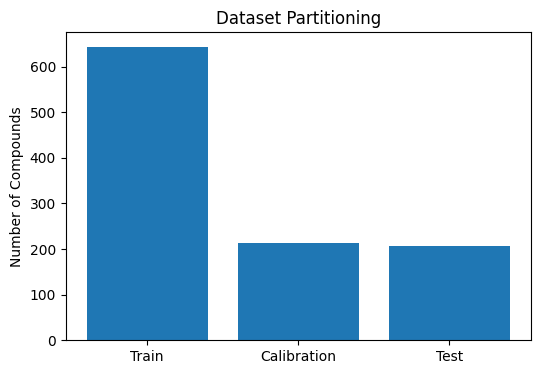

In [7]:
splits = [len(train_compounds), len(cal_compounds), len(test_compounds)]

plt.figure(figsize=(6, 4))
plt.bar(["Train", "Calibration", "Test"], splits)

plt.ylabel("Number of Compounds")
plt.title("Dataset Partitioning")
plt.show()

In [8]:
X_train = physchem_properties.loc[train_compounds, :]
X_cal = physchem_properties.loc[cal_compounds, :]
X_test = physchem_properties.loc[test_compounds, :]

In [9]:
binary_response = pd.read_csv("data/binary_response.tsv", sep="\t", index_col=0)
y_train = binary_response.loc[train_compounds, :]
y_test = binary_response.loc[test_compounds, :]
y_cal = binary_response.loc[cal_compounds, :]

### Random Forest Classifier

A Random Forest is an ensemble method that combines many decision trees.

Advantages:

- Handles high-dimensional descriptor spaces well.
- Captures nonlinear relationships.
- Robust to noisy descriptors.
- Provides class probabilities that can be used by conformal prediction.

The model is trained only on the training set.

In [10]:
rfc = RandomForestClassifier(
    n_estimators=500, max_depth=20, min_samples_leaf=15, random_state=42, class_weight="balanced"
)

In [11]:
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

### Calibration

After training, predictions are generated for the calibration dataset.

For every calibration sample we compute a (non-)conformity score
that measures how compatible the observed class is with the model prediction. In our case, we compute a non-conformity score, which is called true class ($TC$) score, and that measures the probability of being wrong for a particular sample.



#### Intuition behind the CP Sets

As mentioned above, the RF produces a probability for each class. Rather than directly using these probabilities as confidence estimates, we define a *non-conformity score* as the probability that a prediction is wrong.

In [12]:
minimal_certainty = 0.95
true_class_scores = get_pred_score_true_class(
    estimator=rfc, X=X_cal, y=y_cal.values, minimal_certainty=minimal_certainty, class_names=[0, 1]
)

In [13]:
n = len(cal_compounds)
q_class = np.quantile(true_class_scores, math.ceil((n + 1) * minimal_certainty) / n)

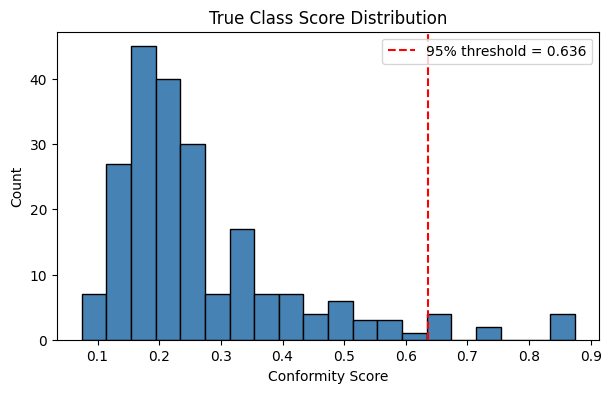

In [14]:
plt.figure(figsize=(7, 4))

plt.hist(true_class_scores, bins=20, color="steelblue", edgecolor="black")

plt.axvline(q_class, color="red", linestyle="--", label=f"95% threshold = {q_class:.3f}")

plt.xlabel("Conformity Score")
plt.ylabel("Count")
plt.title("True Class Score Distribution")
plt.legend()
plt.show()

### Test predictions

For a new compound, we construct the conformal prediction set by including every class whose non-conformity score is below this threshold:

$\{ c : 1-P(c) \le \hat{q} \}$

Intuitively, this means:

- Classes with a sufficiently low probability of being wrong are retained.
- Classes with a probability of being wrong that exceeds the calibrated threshold are excluded.
- If only one class satisfies the criterion, a singleton prediction set is produced.
- If multiple classes satisfy the criterion, the model expresses uncertainty by returning all plausible classes.
- In rare cases no class may satisfy the criterion, resulting in an empty prediction set.

The threshold is chosen such that, on average, the true class will be retained in the prediction set with at least the specified coverage level (e.g. 95%). Therefore, conformal prediction does not aim to identify the single most likely class. Instead, it identifies all classes whose probability of being wrong is sufficiently small to maintain the desired statistical guarantee.


As we consider binary classification, prediction sets can have three outcomes:

- Size 0 (only possible if $\hat{q} < 0.5$):
  insufficient support

- Size 1:
  confident prediction

- Size 2 only possible if $\hat{q} >= 0.5$):
  ambiguous prediction; both classes remain plausible

The more single-class sets are output, i.e., prediction sets containing exactly one class, the more certain is the model and the more _efficient_ is the CP score.

#### Efficiency 
In classification, efficiency is commonly quantified as the fraction of single-class prediction sets over all predictions.

An efficient conformal predictor produces many single-class predictions, while still maintaining the desired ceratinty guarantee, i.e., _coverage_. Prediction sets containing multiple classes indicate uncertainty and are, therefore, less informative.

In [15]:
test_predictions = rfc.predict_proba(X_test)

In [16]:
results = eval_classification_true_class(
    y_pred_proba=test_predictions,
    y_test=y_test.values.flatten(),
    sample_names=y_test.index,
    minimal_certainty=minimal_certainty,
    q=q_class,
    num_classes=2,
    class_names=[0, 1],
)

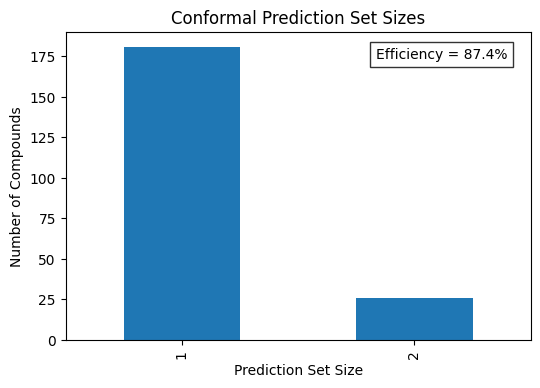

In [17]:
prediction_set_sizes = results["conformal_prediction_95_quantile"].apply(len)

ax = prediction_set_sizes.value_counts().sort_index().plot(kind="bar", figsize=(6, 4))

# efficiency = fraction of singleton prediction sets
singleton_ratio = len(prediction_set_sizes.loc[prediction_set_sizes == 1]) / len(
    prediction_set_sizes
)

ax.text(
    0.95,
    0.95,
    f"Efficiency = {singleton_ratio:.1%}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.8),
)

plt.xlabel("Prediction Set Size")
plt.ylabel("Number of Compounds")
plt.title("Conformal Prediction Set Sizes")
plt.show()

#### Coverage

Coverage measures the validity of the conformal predictor. A prediction is considered covered if the true class is contained within the conformal prediction set. For example, if the prediction set is [0, 1], both classes are considered plausible and the prediction is counted as covered regardless of the true outcome.

The empirical coverage is calculated as the proportion of test compounds whose true label is included in the corresponding conformal prediction set. For a conformal predictor with a minimal certainty level of 95%, the empirical coverage should be close to or above 95%, demonstrating that the uncertainty estimates are well calibrated.

High coverage indicates that the conformal prediction sets reliably contain the true class, while lower-than-expected coverage may suggest violations of the assumptions underlying conformal prediction or insufficient calibration data.

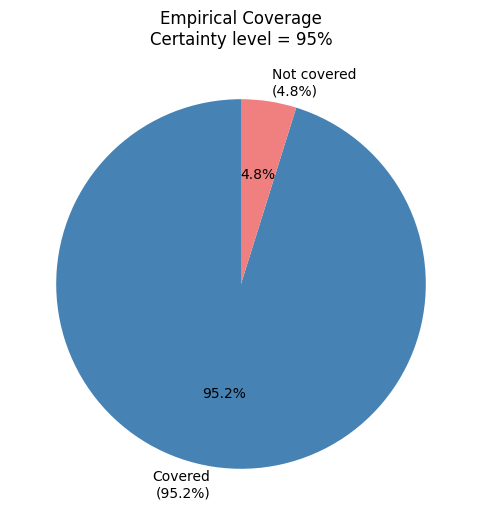

In [18]:
cp_sets = results["conformal_prediction_95_quantile"]

coverage = np.mean([y in pred_set for y, pred_set in zip(results["actual"], cp_sets)])

not_covered = 1 - coverage

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    [coverage, not_covered],
    labels=[f"Covered\n({coverage:.1%})", f"Not covered\n({not_covered:.1%})"],
    colors=["steelblue", "lightcoral"],
    autopct="%1.1f%%",
    startangle=90,
)

ax.set_title(f"Empirical Coverage\nCertainty level = {minimal_certainty:.0%}")

plt.show()

### Conclusions

The RF classifier provides probability estimates for binary classification.

Inductive CP converts these probabilities into statistically
valid prediction sets by calibrating uncertainty on an independent calibration set.

Benefits:

- Rigorous coverage guarantees.
- Explicit uncertainty quantification.
- Improved reliability compared with raw probabilities.

Limitations:

- Requires a dedicated calibration set.
- Larger uncertainty leads to less specific predictions.
- Not really suited for small datasets $\rightarrow$ transductive CP is needed

Overall, CP provides a practical framework for deploying trustworthy
machine learning models in cheminformatics applications.